# Avance 1: Analisis exploratorio del corpus normativo y catalogos regulatorios

Este cuaderno documenta el primer avance del proyecto integrador enfocado en la automatizacion del diseño de requerimientos de informacion financiera mediante tecnicas de Procesamiento de Lenguaje Natural (NLP) y agentes basados en modelos de lenguaje. A diferencia de un problema tabular tradicional, la unidad de analisis principal es un corpus normativo en formato Markdown, complementado por catalogos regulatorios estructurados en el mismo formato.

Desde una perspectiva metodologica, la fase equivalente al Analisis Exploratorio de Datos (EDA) consiste en caracterizar el corpus, identificar ruido documental, justificar el preprocesamiento y establecer una primera relacion entre el texto regulatorio y los diccionarios de negocio ya existentes. Esta labor es relevante porque permite verificar calidad de insumo, reducir complejidad semantica espuria y sentar bases reproducibles para las etapas posteriores como el diseño automatizado de formularios.

## EDA en el contexto de NLP

Dado que la naturaleza de este proyecto se basa en el **Procesamiento de Lenguaje Natural (NLP)** y la extracción estructurada de información, los conceptos tradicionales del Análisis Exploratorio de Datos (EDA) tabular se pueden mapear al análisis de corpus textual de la siguiente:

*   **¿Hay valores faltantes?** En nuestro contexto, esto equivale a párrafos vacíos o errores de lectura en la transformación Word-Markdown. Se abordó en la ingestión inicial filtrando bloques de texto nulos.
*   **¿Cuáles son las estadísticas resumidas?** En lugar de promedios de ventas o edades, calculamos el *conteo de caracteres, tokens (palabras), número de líneas y longitud promedio de palabras* por segmento normativo (Ver **Paso 2**).
*   **¿Hay valores atípicos (outliers)?** Los atípicos aquí son el **ruido documental**: marcas de agua, encabezados repetitivos institucionales ("Hacienda", "CNBV"), y pies de página que no aportan valor semántico. Se mitigaron mediante expresiones regulares (Ver **Paso 3**).
*   **¿Cuál es la cardinalidad de variables categóricas?** Esto se analizó leyendo directamente los **Catálogos Regulatorios** (ej. Tipo de Crédito, Entidades Financieras), determinando el tamaño de nuestro espacio de vocabulario válido (Ver **Paso 4**).
*   **Análisis Bi/Multivariante (Correlación/Relaciones):** Se realizó un análisis de **cobertura semántica** cruzando el corpus normativo limpio contra el vocabulario cerrado de los catálogos para medir cuántas de estas "categorías" están documentadas implícitamente en la ley (Ver **Paso 4**).


In [1]:
from pathlib import Path
import re
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', palette='Blues')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

def resolver_ruta(candidatas):
    for ruta in candidatas:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f'No se encontro ninguno de los archivos esperados: {candidatas}')

cub_path = resolver_ruta([
    PROJECT_ROOT / 'data' / '01_raw' / 'CUB_extracto.md',
    PROJECT_ROOT / 'data' / '02_interim' / 'CUB_extracto.md',
])
catalogo_path = resolver_ruta([
    PROJECT_ROOT / 'data' / '02_interim' / 'catalogos_ml.md',
    PROJECT_ROOT / 'data' / '01_raw' / 'catalogos_ml.md',
])

texto_crudo = cub_path.read_text(encoding='utf-8')
catalogo_md = catalogo_path.read_text(encoding='utf-8')
segmentos_crudos = [bloque.strip() for bloque in re.split(r'\n\s*\n', texto_crudo) if bloque.strip()]

print(f'Archivo CUB cargado desde: {cub_path}')
print(f'Archivo de catalogos cargado desde: {catalogo_path}')
print(f'Longitud total del texto crudo: {len(texto_crudo):,} caracteres')
print(f'Numero preliminar de segmentos textuales: {len(segmentos_crudos):,}')
print(f'Numero de lineas del catalogo Markdown: {len(catalogo_md.splitlines()):,}')

Archivo CUB cargado desde: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\02_interim\CUB_extracto.md
Archivo de catalogos cargado desde: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\02_interim\catalogos_ml.md
Longitud total del texto crudo: 81,971 caracteres
Numero preliminar de segmentos textuales: 483
Numero de lineas del catalogo Markdown: 2,198


## Paso 2. Analisis exploratorio univariante del corpus

En un entorno de NLP, el analisis univariante no se concentra en columnas numericas convencionales, sino en rasgos estructurales del corpus: longitud de segmentos, cantidad de palabras, densidad de tokens y dispersion de tamanos entre articulos, apartados o parrafos. Esta exploracion permite detectar heterogeneidad documental, bloques excesivamente extensos y distribuciones sesgadas que pueden afectar tanto la fragmentacion del contexto como el desempeno de modelos posteriores.

La medicion descriptiva del corpus cumple una funcion equivalente a revisar cardinalidad, dispersion y valores extremos en un EDA tabular: antes de modelar, es necesario conocer la forma estadistica del insumo textual.

,count,mean,std,min,25%,50%,75%,max
n_caracteres,483.0,167.716356,303.601652,3.0,38.000,95.0,175.00,3380.00
n_palabras,483.0,27.494824,47.078436,0.0,6.000,17.0,28.00,506.00
n_lineas,483.0,1.821946,2.698812,1.0,1.000,1.0,1.00,37.00
longitud_promedio_palabra,483.0,4.265466,1.228583,0.0,3.565,4.2,5.09,6.96


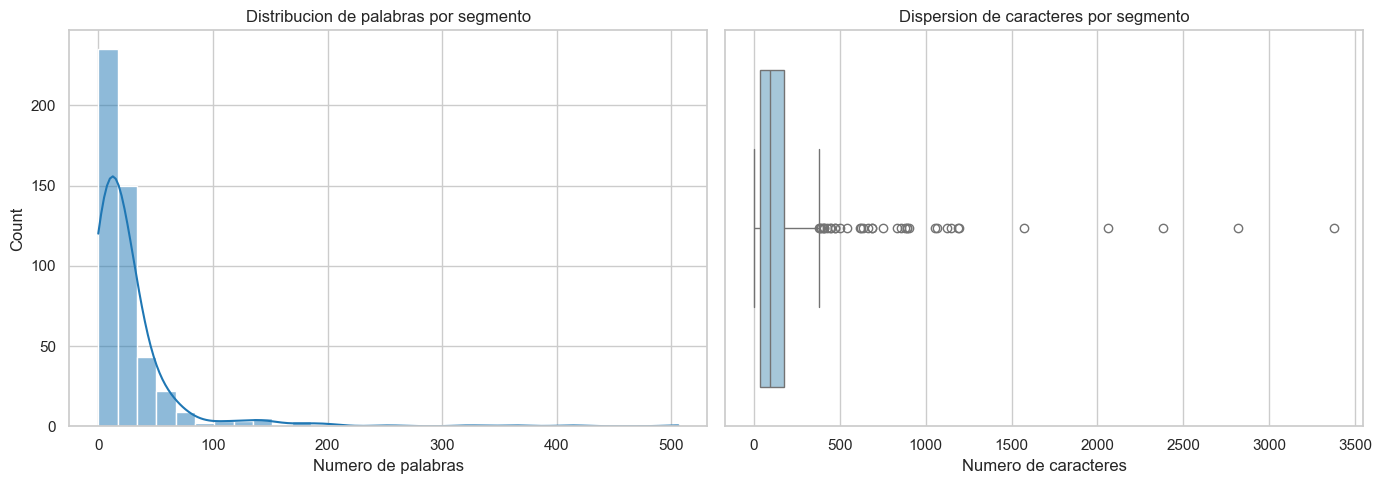

,n_palabras,n_caracteres,segmento
0,506,3380,| Antigüedad del Acreditado en la Institución | Número de meses enteros transcurridos desde la apertura del primer ...
1,413,2819,"| Monto Exigible | El monto que el acreditado debe cubrir en el Periodo de Facturación, el cual deberá considerar t..."
2,364,2379,| Pago Mínimo Exigido | Monto mínimo a la fecha de corte en la cual inicia el Periodo de Pago que el acreditado deb...
3,324,2063,| Tipo de Crédito | Definición |\n| --- | --- |\n| ABCD (B) | A los créditos que sean otorgados a personas física...
4,253,1574,| Reservas Vida Completa_i | = | Monto de reservas a constituir para el i-ésimo crédito en etapa 2. |\n| --- | ---...


In [2]:
def estadisticas_segmento(texto):
    palabras = re.findall(r'\b\w+\b', texto, flags=re.UNICODE)
    return {
        'segmento': texto,
        'n_caracteres': len(texto),
        'n_palabras': len(palabras),
        'n_lineas': len(texto.splitlines()),
        'longitud_promedio_palabra': round(sum(len(p) for p in palabras) / len(palabras), 2) if palabras else 0
    }

df_corpus = pd.DataFrame([estadisticas_segmento(seg) for seg in segmentos_crudos])
display(df_corpus[['n_caracteres', 'n_palabras', 'n_lineas', 'longitud_promedio_palabra']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_corpus, x='n_palabras', bins=30, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de palabras por segmento')
axes[0].set_xlabel('Numero de palabras')

sns.boxplot(data=df_corpus, x='n_caracteres', ax=axes[1], color='#9ecae1')
axes[1].set_title('Dispersion de caracteres por segmento')
axes[1].set_xlabel('Numero de caracteres')

plt.tight_layout()
plt.show()

segmentos_mas_largos = df_corpus.nlargest(5, 'n_palabras')[['n_palabras', 'n_caracteres', 'segmento']]
display(segmentos_mas_largos.reset_index(drop=True))

## Paso 3. Identificacion y tratamiento de valores atipicos documentales

En este proyecto, los valores atipicos los podemos interpretar como patrones de ruido documental que alteran artificialmente la representacion del lenguaje. Encabezados institucionales repetidos, pies de pagina, marcas de control editorial y residuos del proceso de extraccion introducen tokens sin valor semantico para la tarea final.

Por ello, el preprocesamiento mediante expresiones regulares constituye una fase analoga al tratamiento de outliers en analitica clasica: elimina variacion no informativa, reduce dimensionalidad y mejora la relacion senal-ruido del corpus antes de alimentar a un agente LLM.

In [3]:
import re

def limpieza_universal(texto: str) -> str:
    """
    Limpieza genérica aplicable a cualquier documento normativo extraído (PDF/Word a MD).
    Elimina caracteres residuales, dobles espacios y saltos de línea excesivos.
    """
    # Eliminar símbolos residuales extraños de parsers OCR o PDF
    texto = re.sub(r'\^\{\}\[\]', '', texto)
    texto = re.sub(r'\x0c', '', texto) # Saltos de página ocultos
    
    # Limpiar los saltos de línea excesivos (más de 2 seguidos se vuelven 2)
    texto = re.sub(r'\n{3,}', '\n\n', texto)
    
    # Quitar espacios múltiples horizontales
    texto = re.sub(r'[ \t]+', ' ', texto)
    
    return texto.strip()

def limpiar_ruido_cnbv(texto_md: str) -> str:
    """
    Limpia el ruido específico de documentos de la CNBV (ej. Circular Única de Bancos).
    """
    texto_limpio = texto_md
    
    # 1. Quitar las marcas de control de la CNBV al inicio de línea (ej: "(274) ", "(214) ")
    texto_limpio = re.sub(r'^\(\d+\)\s*', '', texto_limpio, flags=re.MULTILINE)
    
    # 2. Quitar el pie de página recurrente (dirección y teléfonos de CNBV)
    pie_pagina_regex = r'Insurgentes Sur 1971.*?www\.gob\.mx/cnbv'
    texto_limpio = re.sub(pie_pagina_regex, '', texto_limpio, flags=re.DOTALL)
    
    # 3. Quitar encabezados institucionales repetitivos de CNBV / SHCP
    encabezados_basura = [
        r'^Hacienda Secretaría de Hacienda y Crédito Público$',
        r'^CNBV$',
        r'^CONSEJO NACIONAL.*$'
    ]
    for patron in encabezados_basura:
        texto_limpio = re.sub(patron, '', texto_limpio, flags=re.MULTILINE)
        
    return texto_limpio

def limpiar_ruido_banxico(texto_md: str) -> str:
    """
    Limpia el ruido específico de documentos del Banco de México (ej. Circulares).
    (Placeholder para futuras reglas específicas de Banxico)
    """
    texto_limpio = texto_md
    # Aquí se pueden agregar expresiones regulares para pies de página de Banxico
    # Ej: "Banco de México - Av. 5 de Mayo..."
    return texto_limpio

def procesar_documento(texto_crudo: str, origen: str = "UNIVERSAL") -> str:
    """
    Orquestador principal. Aplica la limpieza específica por dominio y luego la universal.
    
    Args:
        texto_crudo (str): Texto en markdown o plano a limpiar.
        origen (str): Dominio del documento ('CNBV', 'BANXICO', 'UNIVERSAL').
    """
    if origen.upper() == "CNBV":
        texto = limpiar_ruido_cnbv(texto_crudo)
    elif origen.upper() == "BANXICO":
        texto = limpiar_ruido_banxico(texto_crudo)
    else:
        texto = texto_crudo
        
    return limpieza_universal(texto)


In [4]:
def procesar_documento(texto_md, origen="CNBV"):
    texto_limpio = re.sub(r'^\(\d+\)\s*', '', texto_md, flags=re.MULTILINE)
    texto_limpio = re.sub(r'Insurgentes Sur 1971.*?www\.gob\.mx/cnbv', '', texto_limpio, flags=re.DOTALL)
    for patron in [
        r'^Hacienda Secretaria de Hacienda y Credito Publico$',
        r'^Hacienda Secretaría de Hacienda y Crédito Público$',
        r'^CNBV$',
        r'^CONSEJO NACIONAL.*$',
        r'\^\{\}\[\]'
    ]:
        texto_limpio = re.sub(patron, '', texto_limpio, flags=re.MULTILINE)
        texto_limpio = re.sub(r'\n{3,}', '\n\n', texto_limpio)
    return texto_limpio.strip()

patrones_ruido = {
    'marcas_cnbv': r'^\(\d+\)\s*',
    'pie_pagina': r'Insurgentes Sur 1971.*?www\.gob\.mx/cnbv',
    'encabezado_hacienda': r'^Hacienda Secretaría de Hacienda y Crédito Público$',
    'encabezado_cnbv': r'^CNBV$',
    'residuo_parser': r'\^\{\}\[\]'
}

conteo_ruido = {
    nombre: len(re.findall(patron, texto_crudo, flags=re.MULTILINE | re.DOTALL))
    for nombre, patron in patrones_ruido.items()
}
texto_limpio = procesar_documento(texto_crudo, origen="CNBV")

antes = texto_crudo[:1800]
despues = texto_limpio[:1800]

display(pd.DataFrame(list(conteo_ruido.items()), columns=['patron', 'conteo_detectado']))
display(Markdown('### Muestra antes de la limpieza'))
print(antes)
display(Markdown('### Muestra despues de la limpieza'))
print(despues)

reduccion_absoluta = len(texto_crudo) - len(texto_limpio)
reduccion_relativa = reduccion_absoluta / len(texto_crudo)
print(f'Reduccion de caracteres: {reduccion_absoluta:,} ({reduccion_relativa:.2%})')

,patron,conteo_detectado
0,marcas_cnbv,130
1,pie_pagina,29
2,encabezado_hacienda,26
3,encabezado_cnbv,17
4,residuo_parser,4


### Muestra antes de la limpieza

Hacienda Secretaría de Hacienda y Crédito Público

CNBV

CONSEJO NACIONAL BANCEDAR PRESIDENCIA Y DE VIGILANZA

^{}[]

(275) Artículo 89 Bis.- Las Instituciones, para efecto del cálculo y constitución de las reservas preventivas para riesgos crediticios, deberán calificar desde su reconocimiento inicial los créditos de su Cartera Crediticia con base en el criterio de incremento significativo del riesgo crediticio. Dicho criterio se aplicará desde el momento de la originación y durante toda la vida del crédito, aun cuando este haya sido renovado o reestructurado, y permitirá clasificar cada crédito en una de las tres etapas de riesgo de crédito de conformidad con el Criterio B-6 "Cartera de Crédito" de los Criterios Contables y el Capítulo V Bis del Título Segundo de las presentes disposiciones.

(275) Las Instituciones, podrán optar por alguno de los enfoques siguientes:

(275) I. El Enfoque Estándar, el cual resulta aplicable a todas las carteras consideradas en la definición de Carter

### Muestra despues de la limpieza

Artículo 89 Bis.- Las Instituciones, para efecto del cálculo y constitución de las reservas preventivas para riesgos crediticios, deberán calificar desde su reconocimiento inicial los créditos de su Cartera Crediticia con base en el criterio de incremento significativo del riesgo crediticio. Dicho criterio se aplicará desde el momento de la originación y durante toda la vida del crédito, aun cuando este haya sido renovado o reestructurado, y permitirá clasificar cada crédito en una de las tres etapas de riesgo de crédito de conformidad con el Criterio B-6 "Cartera de Crédito" de los Criterios Contables y el Capítulo V Bis del Título Segundo de las presentes disposiciones.

Las Instituciones, podrán optar por alguno de los enfoques siguientes:

I. El Enfoque Estándar, el cual resulta aplicable a todas las carteras consideradas en la definición de Cartera Crediticia contenida en el Artículo 1 de las presentes disposiciones. Las Instituciones que adopten este enfoque para el cálculo de su

## Paso 4. Analisis relacional entre el texto regulatorio y los catalogos

El analisis bivariado, en este contexto, se formula como una comparacion entre dos fuentes semanticas: el discurso normativo y los diccionarios regulatorios previamente estructurados. La pregunta analitica no es solamente cuantas veces aparece un termino, sino en que medida el vocabulario del catalogo ya se encuentra representado en la regulacion.

Este cruce resulta util para medir cobertura conceptual, anticipar tareas de normalizacion y justificar que los catalogos pueden operar como conocimiento auxiliar para guiar extraccion de entidades, homologacion terminologica y validacion automatizada.

Tablas detectadas en el documento de catalogos: 6
Primeras tablas identificadas: ['entidades_financieras_ml', 'relacion_institucion_filial', 'conceptos_ml', 'concepto_seccion_plazo_ml', 'moneda']


,clave,nombre
0,37006,bancomext
1,37009,banobras
2,37019,banjercito
3,37135,nafin
4,37166,banco del bienestar


C:\Users\Alexandro\AppData\Local\Temp\ipykernel_17392\258960759.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_textuales = df_tabla.select_dtypes(include='object').columns
C:\Users\Alexandro\AppData\Local\Temp\ipykernel_17392\258960759.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pyda

Terminos textuales extraidos del catalogo: 1,357
Terminos encontrados al menos una vez en la CUB limpia: 7
Cobertura inicial aproximada: 0.52%


,termino_catalogo,ocurrencias_en_cub
5,iii,8
4,concepto,5
6,plazo,4
1,0.5,2
2,base,2
3,cartera de consumo,2
0,0.25,1


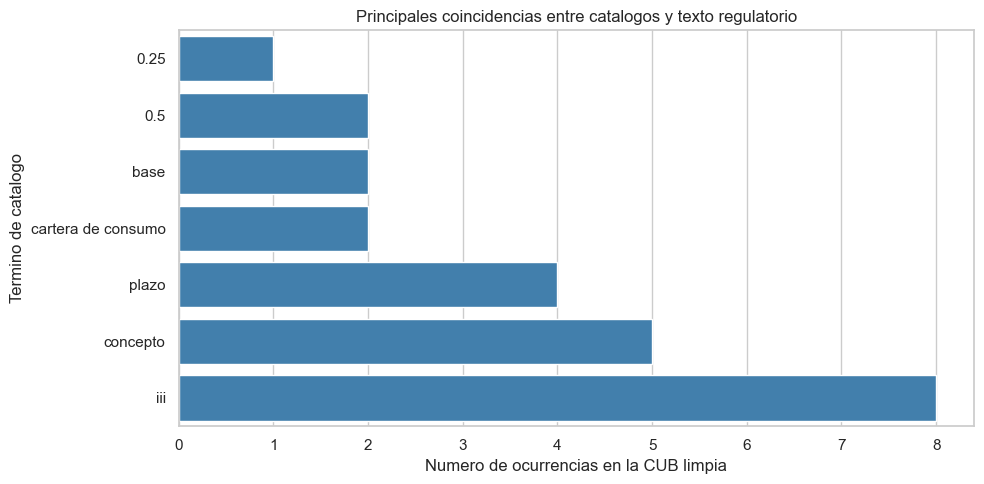

In [5]:
def parsear_tablas_markdown(md_texto):
    tablas = {}
    lineas = md_texto.splitlines()
    nombre_actual = 'tabla_sin_nombre'
    i = 0

    while i < len(lineas):
        linea = lineas[i].strip()

        if linea.startswith('## Tabla / Pestaña:'):
            nombre_actual = linea.split(':', 1)[1].strip()
            i += 1
            continue

        if linea.startswith('|') and i + 1 < len(lineas):
            separador = lineas[i + 1].strip()
            if separador.startswith('|') and set(separador.replace('|', '').replace(':', '').replace('-', '').strip()) == set():
                encabezados = [col.strip() for col in linea.strip('|').split('|')]
                filas = []
                i += 2
                while i < len(lineas) and lineas[i].strip().startswith('|'):
                    valores = [col.strip() for col in lineas[i].strip().strip('|').split('|')]
                    if len(valores) == len(encabezados):
                        filas.append(valores)
                    i += 1
                tablas[nombre_actual] = pd.DataFrame(filas, columns=encabezados)
                continue

        i += 1

    return tablas

tablas_catalogo = parsear_tablas_markdown(catalogo_md)
print(f'Tablas detectadas en el documento de catalogos: {len(tablas_catalogo)}')
print('Primeras tablas identificadas:', list(tablas_catalogo.keys())[:5])

tabla_entidades = tablas_catalogo.get('entidades_financieras_ml', pd.DataFrame())
display(tabla_entidades.head())

texto_limpio_minusculas = texto_limpio.lower()
terminos_catalogo = set()

for nombre_tabla, df_tabla in tablas_catalogo.items():
    columnas_textuales = df_tabla.select_dtypes(include='object').columns
    for columna in columnas_textuales:
        for valor in df_tabla[columna].dropna().astype(str):
            valor = re.sub(r'\s+', ' ', valor.strip().lower())
            if len(valor) >= 3 and not valor.isdigit():
                terminos_catalogo.add(valor)

coincidencias = []
for termino in sorted(terminos_catalogo):
    ocurrencias = len(re.findall(rf'(?<!\w){re.escape(termino)}(?!\w)', texto_limpio_minusculas))
    if ocurrencias > 0:
        coincidencias.append({'termino_catalogo': termino, 'ocurrencias_en_cub': ocurrencias})

coincidencias_df = pd.DataFrame(coincidencias).sort_values('ocurrencias_en_cub', ascending=False) if coincidencias else pd.DataFrame(columns=['termino_catalogo', 'ocurrencias_en_cub'])

cobertura = len(coincidencias_df) / len(terminos_catalogo) if terminos_catalogo else 0
print(f'Terminos textuales extraidos del catalogo: {len(terminos_catalogo):,}')
print(f'Terminos encontrados al menos una vez en la CUB limpia: {len(coincidencias_df):,}')
print(f'Cobertura inicial aproximada: {cobertura:.2%}')

display(coincidencias_df.head(20))

if not coincidencias_df.empty:
    top_n = coincidencias_df.head(15).sort_values('ocurrencias_en_cub')
    sns.barplot(data=top_n, x='ocurrencias_en_cub', y='termino_catalogo', color='#3182bd')
    plt.title('Principales coincidencias entre catalogos y texto regulatorio')
    plt.xlabel('Numero de ocurrencias en la CUB limpia')
    plt.ylabel('Termino de catalogo')
    plt.tight_layout()
    plt.show()
else:
    print('No se detectaron coincidencias exactas con los terminos extraidos del catalogo.')

## Paso 5. Conclusiones del EDA

El ejercicio exploratorio confirma que, aun cuando la fuente principal es texto normativo no estructurado, es posible traducir los principios del EDA clasico a un marco de NLP aplicado. La caracterizacion del corpus permite cuantificar su heterogeneidad; la deteccion de ruido documental justifica tecnicamente el uso de expresiones regulares; y el cruce con catalogos regulatorios muestra que existe una base inicial para vincular el lenguaje normativo con diccionarios operativos.

En terminos de modelado, disponer de un texto limpio y semantica mas concentrada favorece la reduccion de dimensionalidad efectiva, mejora la recuperacion de contexto util y disminuye la probabilidad de que un agente LLM aprenda patrones espurios asociados a encabezados o marcas editoriales. En consecuencia, esta etapa no solo depura datos, sino que fortalece la capacidad de generalizacion del sistema que posteriormente debera identificar conceptos, reglas, validaciones y estructuras requeridas para el diseno automatizado de requerimientos regulatorios.

In [7]:
resumen_final = pd.DataFrame({
    'metrica': [
        'Segmentos analizados',
        'Caracteres antes de limpieza',
        'Caracteres despues de limpieza',
        'Reduccion relativa del texto',
        'Terminos de catalogo evaluados',
        'Terminos con presencia en la CUB'
    ],
    'valor': [
        len(df_corpus),
        len(texto_crudo),
        len(texto_limpio),
        f'{(len(texto_crudo) - len(texto_limpio)) / len(texto_crudo):.2%}',
        len(terminos_catalogo),
        len(coincidencias_df)
    ]
})

display(resumen_final)

,metrica,valor
0,Segmentos analizados,483
1,Caracteres antes de limpieza,81971
2,Caracteres despues de limpieza,75079
3,Reduccion relativa del texto,8.41%
4,Terminos de catalogo evaluados,1357
5,Terminos con presencia en la CUB,7


### Sintesis automatizada del avance

La depuracion del corpus elimino una proporcion relevante de caracteres no informativos y preservo el contenido normativo central.
La exploracion descriptiva evidencio dispersion en la longitud de los segmentos, lo que justifica futuras estrategias de fragmentacion controlada para ingestion en LLMs.
Finalmente, el cruce con los catalogos confirma que ya existe una base terminologica reutilizable para apoyar la extraccion de conceptos y la construccion de validaciones regulatorias en fases posteriores.


## Anexo: Funciones de Ingesta (Parsers)

Se incluyen a continuación de manera informativa las rutinas de extracción usadas para leer los documentos regulatorios originales (Word) y los catálogos (Excel) para convertirlos al formato unificado Markdown (`.md`).

In [1]:
import pandas as pd
import os
import logging
import docx
from docx.document import Document
from docx.oxml.table import CT_Tbl
from docx.oxml.text.paragraph import CT_P
from docx.table import _Cell, Table
from docx.text.paragraph import Paragraph

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ==========================================
# EXCEL PARSER
# ==========================================
def extraer_tablas_excel_a_md(ruta_excel: str, ruta_salida_md: str) -> None:
    try:
        archivo_xls = pd.ExcelFile(ruta_excel)
        nombres_hojas = archivo_xls.sheet_names
        
        with open(ruta_salida_md, 'w', encoding='utf-8') as archivo_md:
            nombre_base = os.path.basename(ruta_excel).replace('.xlsx', '')
            archivo_md.write(f"# Documento: {nombre_base}\n\n")
            
            for hoja in nombres_hojas:
                df = pd.read_excel(ruta_excel, sheet_name=hoja)
                df = df.fillna("") 
                archivo_md.write(f"## Tabla / Pestaña: {hoja}\n\n")
                tabla_markdown = df.to_markdown(index=False)
                archivo_md.write(tabla_markdown + "\n\n")
                
        logger.info(f"Éxito: {len(nombres_hojas)} pestañas convertidas. Guardado en '{ruta_salida_md}'")
        
    except Exception as e:
        logger.exception(f"Error inesperado al procesar el archivo Excel: {e}")

# ==========================================
# WORD PARSER
# ==========================================
def iter_block_items(parent):
    if isinstance(parent, Document):
        parent_elm = parent.element.body
    elif isinstance(parent, _Cell):
        parent_elm = parent._tc
    else:
        raise ValueError("El elemento padre debe ser un Documento o una Celda")

    for child in parent_elm.iterchildren():
        if isinstance(child, CT_P):
            yield Paragraph(child, parent)
        elif isinstance(child, CT_Tbl):
            yield Table(child, parent)

def limpiar_texto_celda(texto: str) -> str:
    if not texto:
        return ""
    return texto.replace('\n', ' ').replace('\r', '').strip()

def extraer_texto_y_tablas_word_a_md(ruta_word: str, ruta_salida_md: str) -> None:
    try:
        doc = docx.Document(ruta_word)
        with open(ruta_salida_md, 'w', encoding='utf-8') as archivo_md:
            nombre_base = os.path.basename(ruta_word)
            archivo_md.write(f"# Documento: {nombre_base}\n\n")
            
            for item in iter_block_items(doc):
                if isinstance(item, Paragraph):
                    texto = item.text.strip()
                    if texto:
                        estilo = item.style.name.lower() if item.style else ""
                        if 'heading 1' in estilo or 'título 1' in estilo:
                            archivo_md.write(f"## {texto}\n\n")
                        elif 'heading 2' in estilo or 'título 2' in estilo:
                            archivo_md.write(f"### {texto}\n\n")
                        elif 'heading 3' in estilo or 'título 3' in estilo:
                            archivo_md.write(f"#### {texto}\n\n")
                        else:
                            archivo_md.write(f"{texto}\n\n")
                            
                elif isinstance(item, Table):
                    datos_tabla = []
                    for row in item.rows:
                        fila_datos = [limpiar_texto_celda(cell.text) for cell in row.cells]
                        datos_tabla.append(fila_datos)
                    
                    if datos_tabla and len(datos_tabla) > 1:
                        df = pd.DataFrame(datos_tabla[1:], columns=datos_tabla[0])
                        df = df.fillna("")
                        tabla_markdown = df.to_markdown(index=False)
                        archivo_md.write(tabla_markdown + "\n\n")
                    elif len(datos_tabla) == 1:
                        fila = " | ".join(datos_tabla[0])
                        separador = " | ".join(["---"] * len(datos_tabla[0]))
                        archivo_md.write(f"| {fila} |\n")
                        archivo_md.write(f"| {separador} |\n\n")
                        
        logger.info(f"Éxito: Documento Word convertido y guardado en '{ruta_salida_md}'")
        
    except Exception as e:
        logger.exception(f"Error inesperado al procesar el archivo Word: {e}")